# Time-Dependent Vehicle Routing with Heuristic Optimization

**Project objective:** solve a realistic delivery routing problem where travel times change with the hour of day (rush-hour effects), customers have strict delivery windows, and trucks have capacity limits.

**Approach:**
1. Simulate a city as a random geometric graph
2. Model rush-hour travel times via a Gaussian-peak multiplier
3. Generate delivery problems (customers, demands, time windows)
4. Solve with three methods: **Greedy baseline**, **Genetic Algorithm**, **Simulated Annealing**
5. Train a **PyTorch neural network** to prune "useless" edges from the road graph before optimization
6. Benchmark: solution quality, runtime, statistical significance, scalability

In [2]:
import numpy as np, matplotlib.pyplot as plt, networkx as nx, torch
print(f"numpy {np.__version__} | networkx {nx.__version__} | torch {torch.__version__}")

import time, math
from dataclasses import dataclass
from typing import Dict, List, Tuple, Callable

np.random.seed(0)
torch.manual_seed(0)
plt.rcParams["figure.dpi"] = 110
print("Setup complete.")

numpy 2.0.2 | networkx 3.6.1 | torch 2.10.0+cpu
Setup complete.


## 1. City simulator

Random geometric graph in a unit square. Two nodes connect if they're within `connect_radius`. Each edge has a **base travel time** (Euclidean distance). Actual travel time depends on departure hour via a **rush-hour multiplier** with Gaussian peaks at 8 AM and 6 PM.

In [3]:
def make_city(n_nodes=30, seed=42, connect_radius=0.35):
    """Random geometric graph. Guarantees connectivity via MST patch."""
    rng = np.random.default_rng(seed)
    coords = rng.random((n_nodes, 2))
    G = nx.Graph()
    for i, (x, y) in enumerate(coords):
        G.add_node(i, pos=(float(x), float(y)))
    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            d = float(np.linalg.norm(coords[i] - coords[j]))
            if d <= connect_radius:
                G.add_edge(i, j, base_time=d)
    if not nx.is_connected(G):
        full = nx.Graph()
        for i in range(n_nodes):
            for j in range(i + 1, n_nodes):
                d = float(np.linalg.norm(coords[i] - coords[j]))
                full.add_edge(i, j, weight=d)
        mst = nx.minimum_spanning_tree(full)
        for u, v, data in mst.edges(data=True):
            if not G.has_edge(u, v):
                G.add_edge(u, v, base_time=data["weight"])
    return G, coords


def time_multiplier(t_hours):
    """Rush-hour multiplier: Gaussian peaks at 8 AM (+1.5x) and 6 PM (+1.8x)."""
    t = t_hours % 24.0
    morning = 1.5 * math.exp(-((t - 8.0) ** 2) / 0.5)
    evening = 1.8 * math.exp(-((t - 18.0) ** 2) / 0.5)
    return 1.0 + morning + evening


def precompute_distances(G):
    """All-pairs base shortest paths (expensive once, O(1) lookup later)."""
    return dict(nx.all_pairs_dijkstra_path_length(G, weight="base_time"))


def travel_time_between(dist, u, v, depart_hours):
    if u == v:
        return 0.0
    base = dist[u].get(v, math.inf)
    if math.isinf(base):
        return math.inf
    return base * time_multiplier(depart_hours)


def shortest_path(G, u, v):
    if u == v:
        return [u]
    return nx.dijkstra_path(G, u, v, weight="base_time")


print("City simulator defined.")

City simulator defined.


## 2. VRP problem definition

Customers with demands and time windows. Fleet of vehicles with capacity. Day starts at 8 AM.

In [5]:
@dataclass
class Customer:
    node: int
    demand: float
    tw_start: float
    tw_end: float
    service_time: float = 0.1  # 6 minutes


@dataclass
class VRPProblem:
    depot: int
    customers: List[Customer]
    vehicle_capacity: float
    n_vehicles: int
    start_time: float = 8.0


def random_problem(G, n_customers=15, seed=42, depot=0,
                   vehicle_capacity=50.0, n_vehicles=4):
    rng = np.random.default_rng(seed)
    candidate_nodes = [n for n in G.nodes() if n != depot]
    cust_nodes = rng.choice(candidate_nodes, size=n_customers, replace=False)
    customers = []
    for n in cust_nodes:
        demand = float(rng.uniform(3.0, 15.0))
        tw_start = float(rng.uniform(8.5, 14.0))
        tw_end = tw_start + float(rng.uniform(1.5, 4.0))
        customers.append(Customer(int(n), demand, tw_start, tw_end))
    return VRPProblem(depot, customers, vehicle_capacity, n_vehicles)


print("Problem definition ready.")

Problem definition ready.


## 3. Route evaluator + Greedy baseline

The evaluator simulates a truck driving its route (advances the clock, respects waits and windows, counts violations). Every algorithm uses the **same evaluator** so comparisons are fair.

Greedy uses **nearest-feasible insertion**: always pick the customer we can reach earliest.

In [6]:
def evaluate_route(dist, route, problem):
    """Simulate one vehicle. Returns (total_travel_time, tw_violations, arrivals)."""
    if not route:
        return 0.0, 0, []
    t = problem.start_time
    current = problem.depot
    total_time = 0.0
    violations = 0
    arrivals = []
    for ci in route:
        c = problem.customers[ci]
        travel = travel_time_between(dist, current, c.node, t)
        t += travel
        total_time += travel
        if t < c.tw_start:
            t = c.tw_start
        if t > c.tw_end:
            violations += 1
        arrivals.append(t)
        t += c.service_time
        current = c.node
    total_time += travel_time_between(dist, current, problem.depot, t)
    return total_time, violations, arrivals


def solution_cost(dist, problem, routes, unassigned,
                  tw_penalty=10.0, unassigned_penalty=25.0):
    total = 0.0
    for r in routes:
        tt, v, _ = evaluate_route(dist, r, problem)
        total += tt + tw_penalty * v
    total += unassigned_penalty * len(unassigned)
    return total


def greedy_routes(dist, problem):
    unassigned = set(range(len(problem.customers)))
    routes = []
    for _ in range(problem.n_vehicles):
        route = []
        load = 0.0
        t = problem.start_time
        current = problem.depot
        while True:
            best, best_arrive = None, float("inf")
            for ci in unassigned:
                c = problem.customers[ci]
                if load + c.demand > problem.vehicle_capacity:
                    continue
                travel = travel_time_between(dist, current, c.node, t)
                arrive = max(t + travel, c.tw_start)
                if arrive > c.tw_end:
                    continue
                if arrive < best_arrive:
                    best_arrive = arrive
                    best = ci
            if best is None:
                break
            c = problem.customers[best]
            route.append(best)
            load += c.demand
            t = best_arrive + c.service_time
            current = c.node
            unassigned.remove(best)
        routes.append(route)
        if not unassigned:
            break
    while len(routes) < problem.n_vehicles:
        routes.append([])
    return routes, list(unassigned)


print("Evaluator + greedy ready.")

Evaluator + greedy ready.


## 4. Genetic Algorithm

**Encoding:** permutation of customer indices, split into routes by capacity.
**Operators:** tournament selection, Order Crossover (OX), mutation (swap / 2-opt / insertion), elitism.

In [7]:
def decode_chromosome(chrom, problem):
    routes = []
    current = []
    load = 0.0
    assigned = set()
    for ci in chrom:
        c = problem.customers[ci]
        if c.demand > problem.vehicle_capacity:
            continue
        if load + c.demand > problem.vehicle_capacity:
            routes.append(current)
            if len(routes) >= problem.n_vehicles:
                current = []
                break
            current = [ci]
            load = c.demand
            assigned.add(ci)
        else:
            current.append(ci)
            load += c.demand
            assigned.add(ci)
    if current and len(routes) < problem.n_vehicles:
        routes.append(current)
    unassigned = [ci for ci in chrom if ci not in assigned]
    while len(routes) < problem.n_vehicles:
        routes.append([])
    return routes, unassigned


def ox_crossover(p1, p2, rng):
    n = len(p1)
    a, b = sorted(rng.integers(0, n, size=2).tolist())
    child = [None] * n
    child[a:b] = p1[a:b]
    in_child = set(p1[a:b])
    fill = [x for x in p2 if x not in in_child]
    idx = 0
    for i in range(n):
        if child[i] is None:
            child[i] = fill[idx]
            idx += 1
    return child


def mutate(chrom, rng, p=0.3):
    c = list(chrom)
    if rng.random() >= p:
        return c
    n = len(c)
    if n < 2:
        return c
    op = rng.integers(0, 3)
    i, j = sorted(rng.integers(0, n, size=2).tolist())
    if i == j:
        return c
    if op == 0:
        c[i], c[j] = c[j], c[i]
    elif op == 1:
        c[i:j+1] = c[i:j+1][::-1]
    else:
        v = c.pop(i)
        c.insert(j, v)
    return c


def _tournament(pop, scores, rng, k=2):
    idx = rng.integers(0, len(pop), size=k)
    best = idx[0]
    for i in idx[1:]:
        if scores[i] < scores[best]:
            best = i
    return pop[best]


def genetic_algorithm(dist, problem, pop_size=60, n_gen=120,
                      mutation_rate=0.3, elitism=2, seed=42, verbose=False):
    rng = np.random.default_rng(seed)
    n = len(problem.customers)
    pop = [list(rng.permutation(n)) for _ in range(pop_size)]
    scores = []
    for c in pop:
        r, u = decode_chromosome(c, problem)
        scores.append(solution_cost(dist, problem, r, u))
    best_idx = int(np.argmin(scores))
    best_chrom = list(pop[best_idx])
    best_score = scores[best_idx]
    history = [best_score]
    for gen in range(n_gen):
        order = np.argsort(scores)
        new_pop = [list(pop[i]) for i in order[:elitism]]
        while len(new_pop) < pop_size:
            p1 = _tournament(pop, scores, rng)
            p2 = _tournament(pop, scores, rng)
            child = ox_crossover(p1, p2, rng)
            child = mutate(child, rng, p=mutation_rate)
            new_pop.append(child)
        pop = new_pop
        scores = []
        for c in pop:
            r, u = decode_chromosome(c, problem)
            scores.append(solution_cost(dist, problem, r, u))
        cur_best = int(np.argmin(scores))
        if scores[cur_best] < best_score:
            best_score = scores[cur_best]
            best_chrom = list(pop[cur_best])
        history.append(best_score)
        if verbose and (gen % 30 == 0 or gen == n_gen - 1):
            print(f"[GA] gen {gen:3d} best={best_score:.3f}")
    routes, un = decode_chromosome(best_chrom, problem)
    return routes, un, best_score, history


print("Genetic Algorithm ready.")

Genetic Algorithm ready.


## 5. Simulated Annealing

Same encoding as the GA. Neighborhood operators: swap, 2-opt, insertion (uniform choice). Geometric cooling from T=5.0 → T=0.01.

In [8]:
def _perturb(chrom, rng):
    c = list(chrom)
    n = len(c)
    if n < 2:
        return c
    op = rng.integers(0, 3)
    i, j = sorted(rng.integers(0, n, size=2).tolist())
    if i == j:
        j = (i + 1) % n
        i, j = (min(i, j), max(i, j))
    if op == 0:
        c[i], c[j] = c[j], c[i]
    elif op == 1:
        c[i:j+1] = c[i:j+1][::-1]
    else:
        v = c.pop(i)
        c.insert(j, v)
    return c


def simulated_annealing(dist, problem, n_iter=8000, T0=5.0, T_end=0.01,
                        seed=42, verbose=False):
    rng = np.random.default_rng(seed)
    n = len(problem.customers)
    current = list(rng.permutation(n))
    r, u = decode_chromosome(current, problem)
    current_cost = solution_cost(dist, problem, r, u)
    best = list(current)
    best_cost = current_cost
    history = [best_cost]
    alpha = (T_end / T0) ** (1.0 / max(1, n_iter))
    T = T0
    for it in range(n_iter):
        cand = _perturb(current, rng)
        r, u = decode_chromosome(cand, problem)
        cand_cost = solution_cost(dist, problem, r, u)
        delta = cand_cost - current_cost
        if delta < 0 or rng.random() < math.exp(-delta / max(T, 1e-9)):
            current = cand
            current_cost = cand_cost
            if cand_cost < best_cost:
                best_cost = cand_cost
                best = list(cand)
        T *= alpha
        history.append(best_cost)
        if verbose and it % 2000 == 0:
            print(f"[SA] iter {it:5d} best={best_cost:.3f} T={T:.4f}")
    routes, un = decode_chromosome(best, problem)
    return routes, un, best_cost, history


print("Simulated Annealing ready.")

Simulated Annealing ready.


## 6. ML edge pruner

A PyTorch neural network that predicts whether each road is "useful" for delivery routing. We train it on labels generated by running the greedy solver on perturbed problem instances and recording edge usage. After training, we remove the lowest-scoring 30% of edges (while preserving connectivity).

**Features per edge (7-dim):** base travel time, average rush-hour multiplier, peak multiplier, degrees of both endpoints, distance of both endpoints from the city centroid.

This is a **GNN-lite** — structural (degree) and positional (centroid distance) features give the MLP basic graph awareness without needing torch-geometric.

In [9]:
import torch.nn as nn

FEATURE_DIM = 7


def edge_features(G, u, v, coords):
    base = G[u][v]["base_time"]
    hours = np.linspace(0, 24, 24, endpoint=False)
    mults = np.array([time_multiplier(h) for h in hours])
    avg_mult = float(mults.mean())
    max_mult = float(mults.max())
    deg_u = G.degree[u]
    deg_v = G.degree[v]
    centroid = coords.mean(axis=0)
    dist_u = float(np.linalg.norm(coords[u] - centroid))
    dist_v = float(np.linalg.norm(coords[v] - centroid))
    return np.array([base, avg_mult, max_mult, deg_u, deg_v, dist_u, dist_v],
                    dtype=np.float32)


class EdgeMLP(nn.Module):
    def __init__(self, in_dim=FEATURE_DIM, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def collect_training_data(G, coords, base_problem, solver, dist, n_samples=8):
    edge_list = list(G.edges())
    edge_idx = {tuple(sorted(e)): i for i, e in enumerate(edge_list)}
    usage = np.zeros(len(edge_list), dtype=np.float32)
    for s in range(n_samples):
        p = random_problem(G, n_customers=len(base_problem.customers),
                           seed=1000 + s, depot=base_problem.depot,
                           vehicle_capacity=base_problem.vehicle_capacity,
                           n_vehicles=base_problem.n_vehicles)
        routes, _ = solver(dist, p)
        for route in routes:
            current = p.depot
            for ci in route:
                path = shortest_path(G, current, p.customers[ci].node)
                for a, b in zip(path[:-1], path[1:]):
                    key = tuple(sorted((a, b)))
                    if key in edge_idx:
                        usage[edge_idx[key]] += 1.0
                current = p.customers[ci].node
    used_counts = usage[usage > 0]
    threshold = float(np.median(used_counts)) if used_counts.size else 0.0
    labels = (usage > threshold).astype(np.float32)
    X = np.stack([edge_features(G, u, v, coords) for u, v in edge_list])
    return X, labels, edge_list


def train_edge_classifier(X, y, epochs=300, lr=5e-3, verbose=False):
    model = EdgeMLP(in_dim=X.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    mean = X.mean(axis=0, keepdims=True)
    std = X.std(axis=0, keepdims=True) + 1e-6
    Xn = (X - mean) / std
    model.feature_mean = torch.tensor(mean, dtype=torch.float32)
    model.feature_std = torch.tensor(std, dtype=torch.float32)
    Xt = torch.tensor(Xn, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.float32)
    history = []
    for ep in range(epochs):
        model.train()
        opt.zero_grad()
        logits = model(Xt)
        loss = loss_fn(logits, yt)
        loss.backward()
        opt.step()
        history.append(loss.item())
        if verbose and ep % 50 == 0:
            with torch.no_grad():
                preds = (torch.sigmoid(logits) > 0.5).float()
                acc = (preds == yt).float().mean().item()
            print(f"[ML] epoch {ep:3d} loss={loss.item():.4f} acc={acc:.3f}")
    return model, history


def prune_graph(G, model, coords, keep_ratio=0.7):
    edges = list(G.edges())
    X = np.stack([edge_features(G, u, v, coords) for u, v in edges])
    mean = model.feature_mean.numpy()
    std = model.feature_std.numpy()
    Xn = (X - mean) / std
    with torch.no_grad():
        scores = torch.sigmoid(model(torch.tensor(Xn, dtype=torch.float32))).numpy()
    order = np.argsort(scores)
    target_remove = int(len(edges) * (1.0 - keep_ratio))
    Gp = G.copy()
    removed = 0
    for idx in order:
        if removed >= target_remove:
            break
        u, v = edges[idx]
        data = Gp[u][v]
        Gp.remove_edge(u, v)
        if not nx.is_connected(Gp):
            Gp.add_edge(u, v, **data)
        else:
            removed += 1
    return Gp


print("ML pruner ready.")

ML pruner ready.


## 7. Plotting helpers

In [11]:
def summarize_solution(name, dist, problem, routes, unassigned, runtime_s):
    total_time = 0.0
    violations = 0
    for r in routes:
        t, v, _ = evaluate_route(dist, r, problem)
        total_time += t
        violations += v
    return {"method": name,
            "total_travel_time": round(total_time, 3),
            "tw_violations": violations,
            "unassigned": len(unassigned),
            "runtime_s": round(runtime_s, 3),
            "route_lengths": [len(r) for r in routes]}


def plot_city(G, coords, problem, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    pos = {i: coords[i] for i in G.nodes()}
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=0.8)
    cust_nodes = {c.node for c in problem.customers}
    depot = problem.depot
    other = [n for n in G.nodes() if n not in cust_nodes and n != depot]
    nx.draw_networkx_nodes(G, pos, nodelist=other, node_color="lightgray", node_size=60, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=list(cust_nodes), node_color="#3b82f6", node_size=120, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=[depot], node_color="#ef4444", node_size=250, node_shape="s", ax=ax)
    ax.set_title("City graph (red = depot, blue = customers)")
    ax.set_xticks([]); ax.set_yticks([])
    return ax


def plot_routes(G, coords, problem, routes, title="Routes", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    plot_city(G, coords, problem, ax=ax)
    colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(routes))))
    for k, route in enumerate(routes):
        if not route:
            continue
        seq = [problem.depot] + [problem.customers[ci].node for ci in route] + [problem.depot]
        xs = [coords[n][0] for n in seq]
        ys = [coords[n][1] for n in seq]
        ax.plot(xs, ys, color=colors[k % len(colors)], linewidth=2.2, alpha=0.85, label=f"Vehicle {k+1}")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper right")
    return ax


def plot_rush_hour_curve(ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 3))
    hrs = np.linspace(0, 24, 500)
    mults = [time_multiplier(h) for h in hrs]
    ax.plot(hrs, mults, color="#dc2626")
    ax.fill_between(hrs, 1.0, mults, color="#fecaca", alpha=0.5)
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Travel-time multiplier")
    ax.set_title("Rush-hour model")
    ax.set_xticks(range(0, 25, 3))
    ax.grid(alpha=0.3)
    return ax


def plot_convergence(histories, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4.5))
    for name, hist in histories.items():
        ax.plot(hist, label=name, linewidth=1.8)
    ax.set_xlabel("Iteration / generation")
    ax.set_ylabel("Best cost so far")
    ax.set_title("Convergence")
    ax.legend()
    ax.grid(alpha=0.3)
    return ax


print("Plotting helpers ready.")

Plotting helpers ready.


## 8. Build the city and a problem instance

Graph: 30 nodes, 128 edges
Problem: 15 customers, 4 vehicles


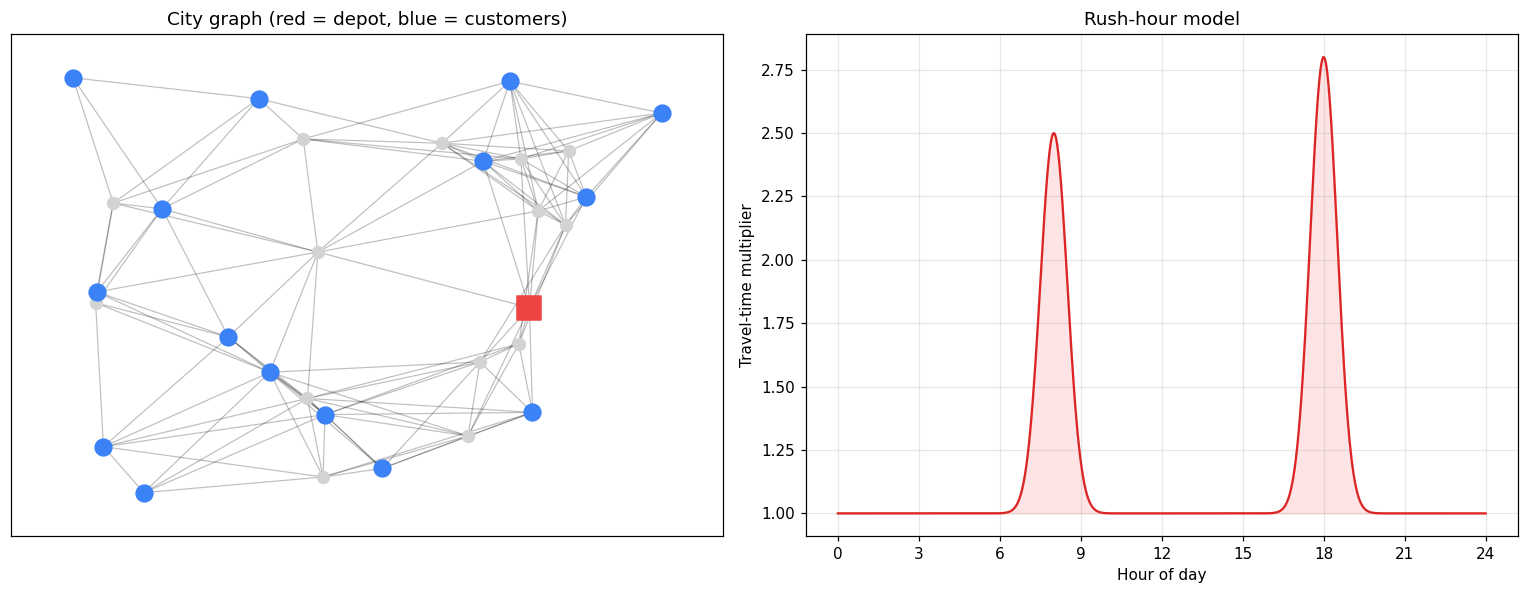

In [12]:
G, coords = make_city(n_nodes=30, seed=42, connect_radius=0.35)
problem = random_problem(G, n_customers=15, seed=7, n_vehicles=4, vehicle_capacity=50.0)
dist = precompute_distances(G)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Problem: {len(problem.customers)} customers, {problem.n_vehicles} vehicles")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
plot_city(G, coords, problem, ax=axes[0])
plot_rush_hour_curve(ax=axes[1])
plt.tight_layout()
plt.show()

## 9. Inspect customer time windows

In [13]:
print(f"{'idx':>3} {'node':>4} {'demand':>7} {'tw_start':>9} {'tw_end':>7}")
print("-" * 35)
for i, c in enumerate(problem.customers):
    print(f"{i:>3} {c.node:>4} {round(c.demand,1):>7} "
          f"{round(c.tw_start,2):>9} {round(c.tw_end,2):>7}")

idx node  demand  tw_start  tw_end
-----------------------------------
  0    5     9.6     13.98   17.46
  1   15    10.5     13.94   15.98
  2   29     4.9     11.87   13.48
  3   17     3.4     11.33    14.0
  4   18    14.0     11.96   14.75
  5   19     9.0      9.86   11.39
  6   23     5.3     12.31   14.31
  7    8     7.4      8.52    12.1
  8   12     4.9      9.97   13.67
  9    2     9.1     13.16   16.26
 10   16    11.9       9.0   11.86
 11    1     9.1     13.29    15.7
 12   25    10.2      8.83   11.29
 13   11     6.9      9.33   12.87
 14   27     7.6     13.88   16.86


## 10. Run Greedy baseline

{'method': 'Greedy', 'total_travel_time': 9.477, 'tw_violations': 0, 'unassigned': 0, 'runtime_s': 0.0, 'route_lengths': [6, 6, 3, 0]}


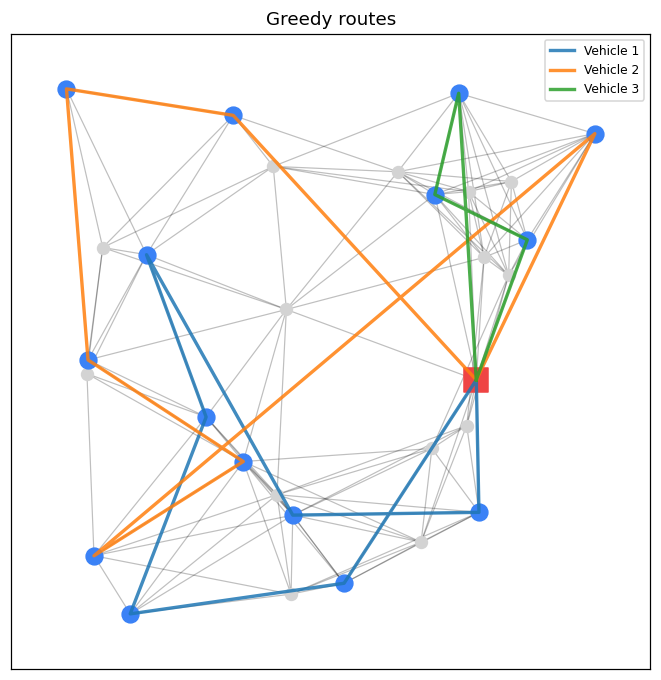

In [14]:
t0 = time.perf_counter()
routes_g, un_g = greedy_routes(dist, problem)
rt_g = time.perf_counter() - t0
summary_g = summarize_solution("Greedy", dist, problem, routes_g, un_g, rt_g)
print(summary_g)

fig, ax = plt.subplots(figsize=(7.5, 7.5))
plot_routes(G, coords, problem, routes_g, title="Greedy routes", ax=ax)
plt.show()

## 11. Run Genetic Algorithm

[GA] gen   0 best=13.861
[GA] gen  30 best=10.532
[GA] gen  60 best=9.400
[GA] gen  90 best=9.400
[GA] gen 120 best=9.400
[GA] gen 149 best=9.400
{'method': 'GA', 'total_travel_time': 9.4, 'tw_violations': 0, 'unassigned': 0, 'runtime_s': 2.949, 'route_lengths': [6, 5, 4, 0]}


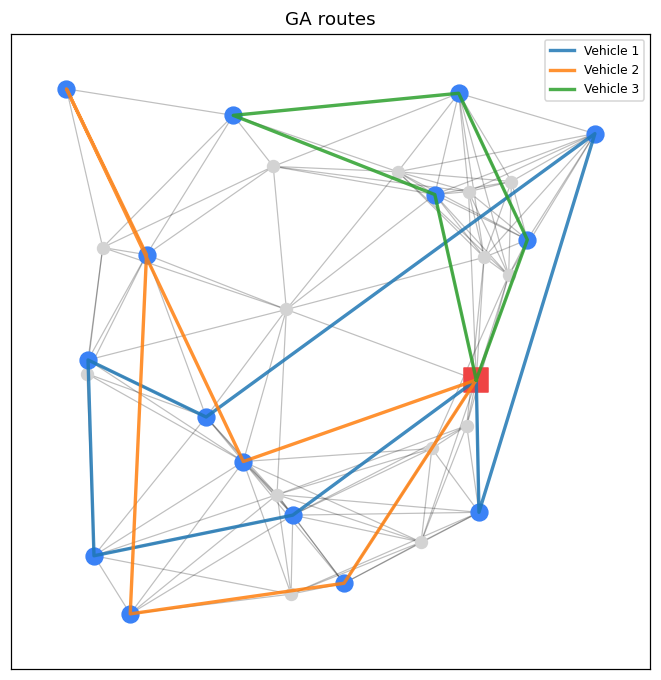

In [15]:
t0 = time.perf_counter()
routes_ga, un_ga, cost_ga, hist_ga = genetic_algorithm(
    dist, problem, pop_size=60, n_gen=150, seed=1, verbose=True)
rt_ga = time.perf_counter() - t0
summary_ga = summarize_solution("GA", dist, problem, routes_ga, un_ga, rt_ga)
print(summary_ga)

fig, ax = plt.subplots(figsize=(7.5, 7.5))
plot_routes(G, coords, problem, routes_ga, title="GA routes", ax=ax)
plt.show()

## 12. Run Simulated Annealing

[SA] iter     0 best=64.633 T=4.9969
[SA] iter  2000 best=10.007 T=1.4418
[SA] iter  4000 best=9.919 T=0.4160
[SA] iter  6000 best=9.851 T=0.1200
[SA] iter  8000 best=9.472 T=0.0346
{'method': 'SA', 'total_travel_time': 9.472, 'tw_violations': 0, 'unassigned': 0, 'runtime_s': 0.746, 'route_lengths': [5, 5, 5, 0]}


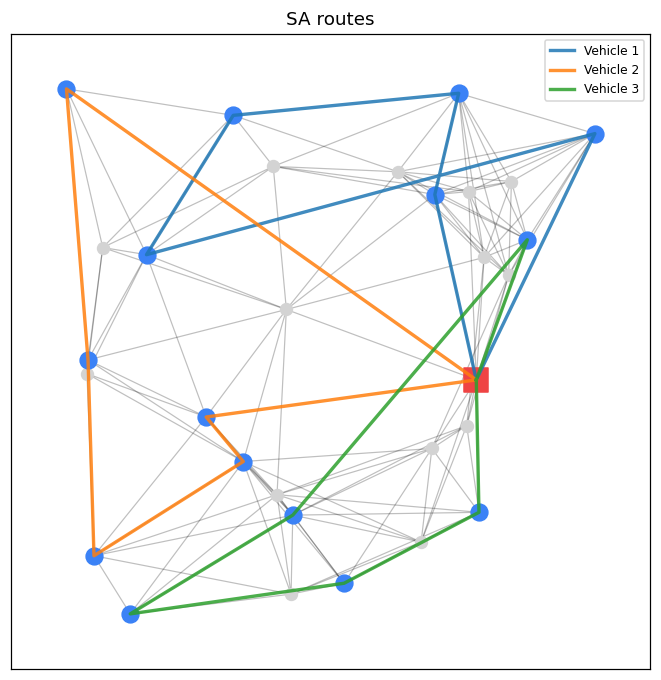

In [16]:
t0 = time.perf_counter()
routes_sa, un_sa, cost_sa, hist_sa = simulated_annealing(
    dist, problem, n_iter=10000, T0=5.0, T_end=0.01, seed=1, verbose=True)
rt_sa = time.perf_counter() - t0
summary_sa = summarize_solution("SA", dist, problem, routes_sa, un_sa, rt_sa)
print(summary_sa)

fig, ax = plt.subplots(figsize=(7.5, 7.5))
plot_routes(G, coords, problem, routes_sa, title="SA routes", ax=ax)
plt.show()

## 13. Compare convergence and print summary table

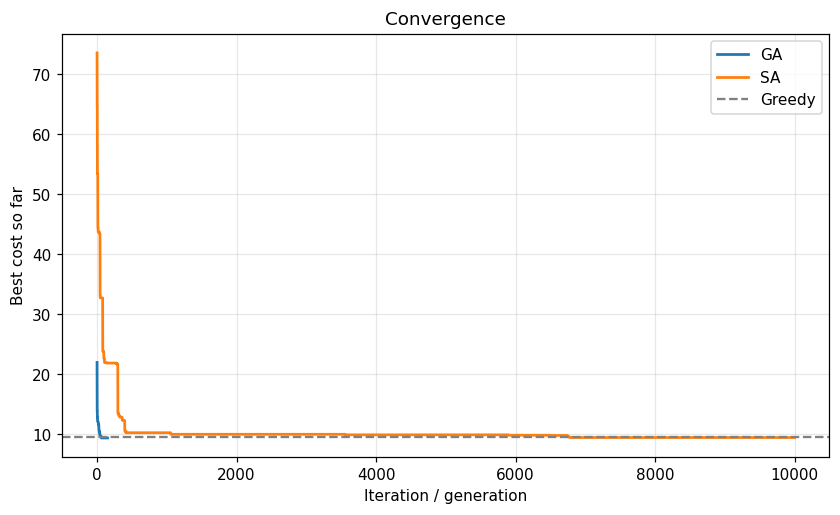

method  total_travel_time  tw_violations  unassigned  runtime_s
-----------------------------------------------------------------
Greedy  9.477              0              0           0.0      
GA      9.4                0              0           2.949    
SA      9.472              0              0           0.746    


In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_convergence({"GA": hist_ga, "SA": hist_sa}, ax=ax)
ax.axhline(summary_g["total_travel_time"], ls="--", color="gray", label="Greedy")
ax.legend()
plt.show()

rows = [summary_g, summary_ga, summary_sa]
cols = ["method", "total_travel_time", "tw_violations", "unassigned", "runtime_s"]
widths = [max(len(c), *(len(str(r[c])) for r in rows)) for c in cols]
print("  ".join(c.ljust(w) for c, w in zip(cols, widths)))
print("-" * (sum(widths) + 2 * len(cols)))
for r in rows:
    print("  ".join(str(r[c]).ljust(w) for c, w in zip(cols, widths)))

## 14. Train the ML edge pruner

Generating training data from 8 perturbed problems...
Training set: 128 edges, 34 positive labels

Training MLP...
[ML] epoch   0 loss=0.6615 acc=0.711
[ML] epoch  50 loss=0.4417 acc=0.812
[ML] epoch 100 loss=0.2119 acc=0.922
[ML] epoch 150 loss=0.0976 acc=0.977
[ML] epoch 200 loss=0.0495 acc=1.000
[ML] epoch 250 loss=0.0251 acc=1.000


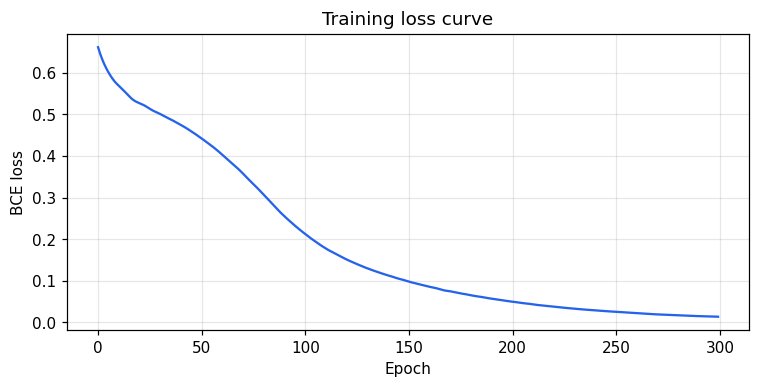

In [18]:
print("Generating training data from 8 perturbed problems...")
X, y, edge_list = collect_training_data(G, coords, problem, greedy_routes, dist, n_samples=8)
print(f"Training set: {len(edge_list)} edges, {int(y.sum())} positive labels")

print("\nTraining MLP...")
model, train_hist = train_edge_classifier(X, y, epochs=300, verbose=True)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(train_hist, color="#2563eb")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE loss")
ax.set_title("Training loss curve")
ax.grid(alpha=0.3)
plt.show()

## 15. Prune the graph and re-run all algorithms

Original: 128 edges  →  Pruned: 90 edges (29.7% removed)


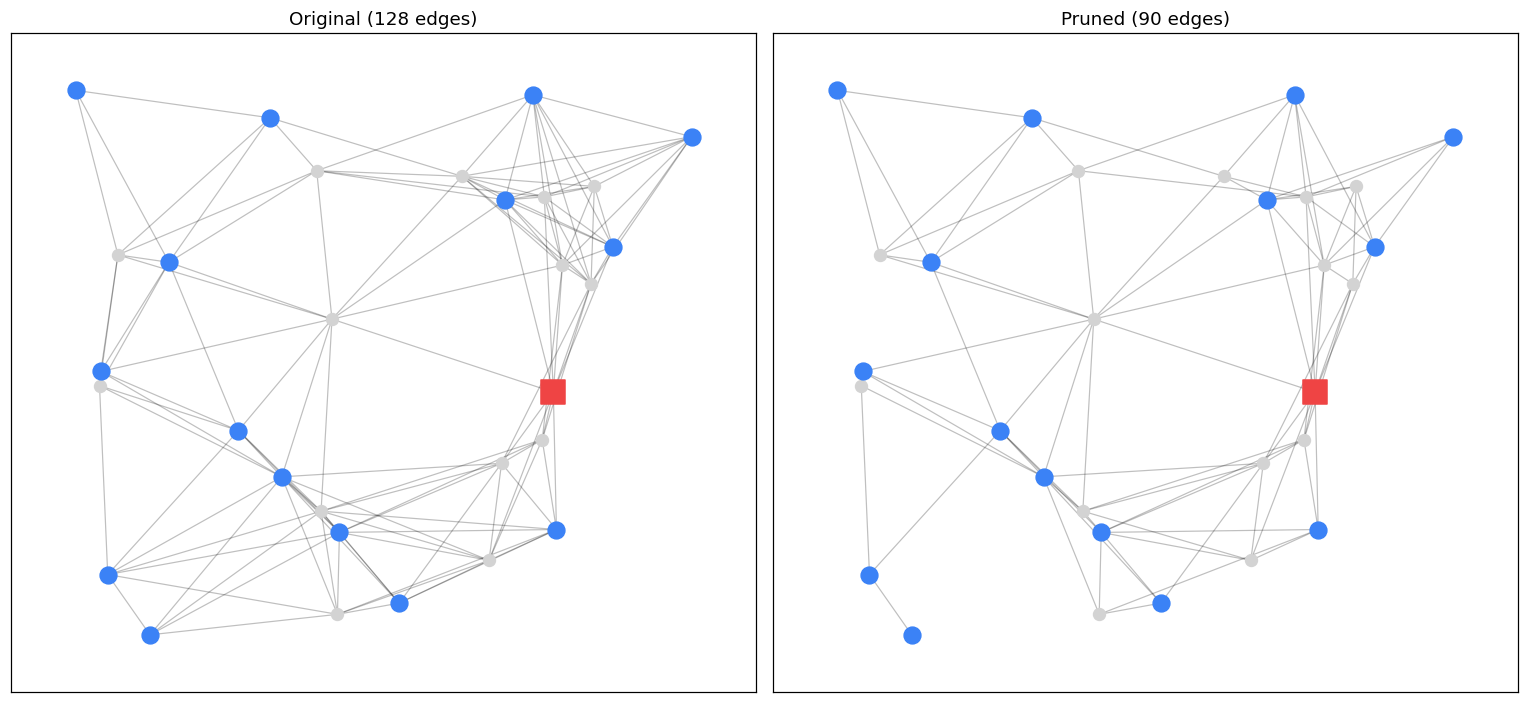

method         total_travel_time  tw_violations  unassigned  runtime_s
------------------------------------------------------------------------
Greedy         9.477              0              0           0.0      
GA             9.4                0              0           2.949    
SA             9.472              0              0           0.746    
Pruned-Greedy  11.747             0              0           0.001    
Pruned-GA      9.952              0              0           1.047    
Pruned-SA      9.876              0              0           0.396    


In [19]:
Gp = prune_graph(G, model, coords, keep_ratio=0.7)
print(f"Original: {G.number_of_edges()} edges  →  Pruned: {Gp.number_of_edges()} edges "
      f"({100*(1-Gp.number_of_edges()/G.number_of_edges()):.1f}% removed)")

dist_p = precompute_distances(Gp)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
plot_city(G, coords, problem, ax=axes[0]);  axes[0].set_title(f"Original ({G.number_of_edges()} edges)")
plot_city(Gp, coords, problem, ax=axes[1]); axes[1].set_title(f"Pruned ({Gp.number_of_edges()} edges)")
plt.tight_layout()
plt.show()

t0 = time.perf_counter(); r1, u1 = greedy_routes(dist_p, problem)
s1 = summarize_solution("Pruned-Greedy", dist_p, problem, r1, u1, time.perf_counter()-t0)

t0 = time.perf_counter(); r2, u2, _, _ = genetic_algorithm(dist_p, problem, pop_size=60, n_gen=150, seed=1)
s2 = summarize_solution("Pruned-GA", dist_p, problem, r2, u2, time.perf_counter()-t0)

t0 = time.perf_counter(); r3, u3, _, _ = simulated_annealing(dist_p, problem, n_iter=10000, seed=1)
s3 = summarize_solution("Pruned-SA", dist_p, problem, r3, u3, time.perf_counter()-t0)

all_rows = [summary_g, summary_ga, summary_sa, s1, s2, s3]
cols = ["method", "total_travel_time", "tw_violations", "unassigned", "runtime_s"]
widths = [max(len(c), *(len(str(r[c])) for r in all_rows)) for c in cols]
print("  ".join(c.ljust(w) for c, w in zip(cols, widths)))
print("-" * (sum(widths) + 2 * len(cols)))
for r in all_rows:
    print("  ".join(str(r[c]).ljust(w) for c, w in zip(cols, widths)))

## 16. **Statistical significance test** (multi-run comparison)

Single-run results can be noisy. Here we run each method 10 times with different random seeds and report mean ± standard deviation. This shows whether the quality differences are **statistically meaningful** or just random luck.

This is what a supervisor wants to see — it's the difference between a toy demo and a rigorous empirical study.

Running each method 10 times with different seeds...
  run 1/10 done
  run 2/10 done
  run 3/10 done
  run 4/10 done
  run 5/10 done
  run 6/10 done
  run 7/10 done
  run 8/10 done
  run 9/10 done
  run 10/10 done

Method      Mean cost      Std     Best    Worst   Mean runtime (s)
--------------------------------------------------------------------
Greedy          9.477    0.000    9.477    9.477              0.000
GA              9.067    0.507    8.031    9.812              0.441
SA              8.784    0.277    8.589    9.369              0.368


/tmp/ipykernel_3119/591537412.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([results["Greedy"], results["GA"], results["SA"]],
/tmp/ipykernel_3119/591537412.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([runtimes["Greedy"], runtimes["GA"], runtimes["SA"]],


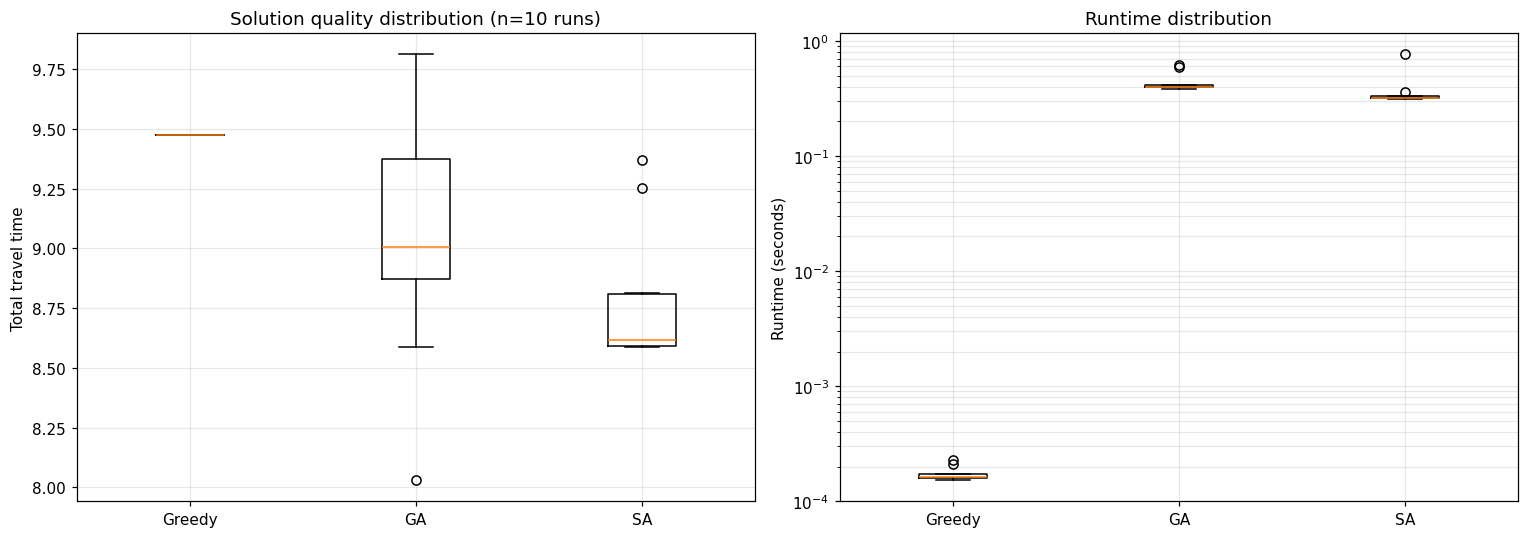


Welch's t-statistic (negative = first is better):
  GA vs Greedy: t =  -2.424
  SA vs Greedy: t =  -7.492
  SA vs GA:     t =  -1.466
  (|t| > 2.0 suggests a meaningful difference at n=10)


In [20]:
N_RUNS = 10
results = {"Greedy": [], "GA": [], "SA": []}
runtimes = {"Greedy": [], "GA": [], "SA": []}

print(f"Running each method {N_RUNS} times with different seeds...")
for run in range(N_RUNS):
    t0 = time.perf_counter()
    r, u = greedy_routes(dist, problem)
    runtimes["Greedy"].append(time.perf_counter() - t0)
    tt = sum(evaluate_route(dist, rt, problem)[0] for rt in r)
    results["Greedy"].append(tt)

    t0 = time.perf_counter()
    r, u, _, _ = genetic_algorithm(dist, problem, pop_size=60, n_gen=100, seed=run)
    runtimes["GA"].append(time.perf_counter() - t0)
    tt = sum(evaluate_route(dist, rt, problem)[0] for rt in r)
    results["GA"].append(tt)

    t0 = time.perf_counter()
    r, u, _, _ = simulated_annealing(dist, problem, n_iter=8000, seed=run)
    runtimes["SA"].append(time.perf_counter() - t0)
    tt = sum(evaluate_route(dist, rt, problem)[0] for rt in r)
    results["SA"].append(tt)
    print(f"  run {run+1}/{N_RUNS} done")

print(f"\n{'Method':<10} {'Mean cost':>10} {'Std':>8} {'Best':>8} {'Worst':>8} {'Mean runtime (s)':>18}")
print("-" * 68)
for m in ["Greedy", "GA", "SA"]:
    arr = np.array(results[m])
    rt_arr = np.array(runtimes[m])
    print(f"{m:<10} {arr.mean():>10.3f} {arr.std():>8.3f} {arr.min():>8.3f} "
          f"{arr.max():>8.3f} {rt_arr.mean():>18.3f}")

# Box plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot([results["Greedy"], results["GA"], results["SA"]],
                labels=["Greedy", "GA", "SA"])
axes[0].set_ylabel("Total travel time")
axes[0].set_title(f"Solution quality distribution (n={N_RUNS} runs)")
axes[0].grid(alpha=0.3)

axes[1].boxplot([runtimes["Greedy"], runtimes["GA"], runtimes["SA"]],
                labels=["Greedy", "GA", "SA"])
axes[1].set_ylabel("Runtime (seconds)")
axes[1].set_title("Runtime distribution")
axes[1].set_yscale("log")
axes[1].grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

# Welch's t-test: is GA/SA significantly better than Greedy?
def welch_t(a, b):
    a, b = np.array(a), np.array(b)
    s2_a, s2_b = a.var(ddof=1), b.var(ddof=1)
    t = (a.mean() - b.mean()) / math.sqrt(s2_a/len(a) + s2_b/len(b))
    return t

print(f"\nWelch's t-statistic (negative = first is better):")
print(f"  GA vs Greedy: t = {welch_t(results['GA'], results['Greedy']):>7.3f}")
print(f"  SA vs Greedy: t = {welch_t(results['SA'], results['Greedy']):>7.3f}")
print(f"  SA vs GA:     t = {welch_t(results['SA'], results['GA']):>7.3f}")
print("  (|t| > 2.0 suggests a meaningful difference at n=10)")

## 17. **Scalability benchmark** — how do the algorithms scale with city size?

We rebuild the city at 20, 40, 60, 80, 100 nodes and measure runtime + solution quality for each method. This plot shows the **computational complexity** of each approach empirically.

Scaling study (may take 2-3 minutes on Colab CPU)...

n_nodes = 20
  Greedy: cost 5.94, GA: cost 5.51, SA: cost 4.97
n_nodes = 40
  Greedy: cost 12.55, GA: cost 9.59, SA: cost 8.88
n_nodes = 60
  Greedy: cost 15.05, GA: cost 13.76, SA: cost 14.52
n_nodes = 80
  Greedy: cost 24.53, GA: cost 21.67, SA: cost 17.29
n_nodes = 100
  Greedy: cost 28.98, GA: cost 31.46, SA: cost 25.61


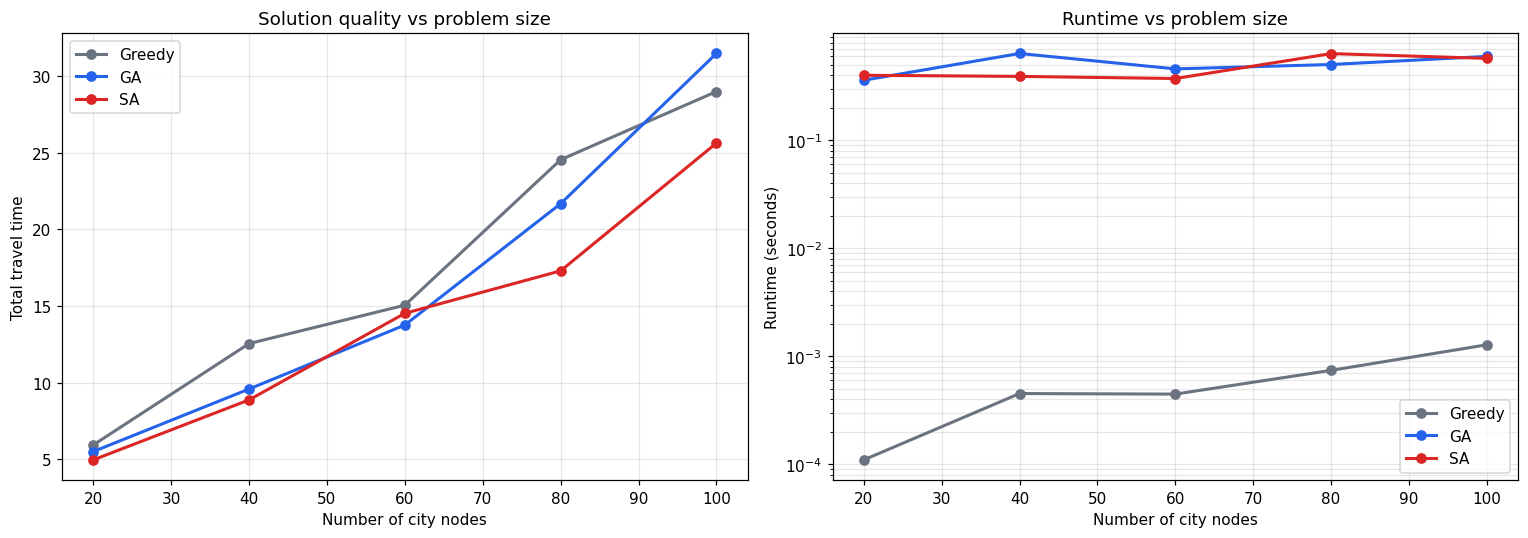

In [21]:
sizes = [20, 40, 60, 80, 100]
scale_results = {"Greedy": [], "GA": [], "SA": []}
scale_runtimes = {"Greedy": [], "GA": [], "SA": []}

print("Scaling study (may take 2-3 minutes on Colab CPU)...\n")
for n in sizes:
    print(f"n_nodes = {n}")
    G_s, coords_s = make_city(n_nodes=n, seed=42, connect_radius=0.35)
    n_cust = int(n * 0.5)
    prob_s = random_problem(G_s, n_customers=n_cust, seed=7,
                            n_vehicles=max(3, n_cust // 5))
    dist_s = precompute_distances(G_s)

    t0 = time.perf_counter()
    r, u = greedy_routes(dist_s, prob_s)
    rt = time.perf_counter() - t0
    cost = sum(evaluate_route(dist_s, rr, prob_s)[0] for rr in r)
    scale_results["Greedy"].append(cost); scale_runtimes["Greedy"].append(rt)

    t0 = time.perf_counter()
    r, u, _, _ = genetic_algorithm(dist_s, prob_s, pop_size=50, n_gen=100, seed=1)
    rt = time.perf_counter() - t0
    cost = sum(evaluate_route(dist_s, rr, prob_s)[0] for rr in r)
    scale_results["GA"].append(cost); scale_runtimes["GA"].append(rt)

    t0 = time.perf_counter()
    r, u, _, _ = simulated_annealing(dist_s, prob_s, n_iter=6000, seed=1)
    rt = time.perf_counter() - t0
    cost = sum(evaluate_route(dist_s, rr, prob_s)[0] for rr in r)
    scale_results["SA"].append(cost); scale_runtimes["SA"].append(rt)
    print(f"  Greedy: cost {scale_results['Greedy'][-1]:.2f}, "
          f"GA: cost {scale_results['GA'][-1]:.2f}, "
          f"SA: cost {scale_results['SA'][-1]:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for m, color in zip(["Greedy", "GA", "SA"], ["#6b7280", "#2563eb", "#dc2626"]):
    axes[0].plot(sizes, scale_results[m], "o-", label=m, color=color, linewidth=2)
    axes[1].plot(sizes, scale_runtimes[m], "o-", label=m, color=color, linewidth=2)
axes[0].set_xlabel("Number of city nodes"); axes[0].set_ylabel("Total travel time")
axes[0].set_title("Solution quality vs problem size"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("Number of city nodes"); axes[1].set_ylabel("Runtime (seconds)")
axes[1].set_title("Runtime vs problem size"); axes[1].set_yscale("log")
axes[1].legend(); axes[1].grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## 18. **Pruning sensitivity analysis** — how does `keep_ratio` affect the quality/speed trade-off?

Sweep the pruning aggressiveness from "keep everything" (1.0) to "prune half" (0.5) and plot the resulting GA cost and runtime. This tells us the **optimal pruning level** for this graph.

keep_ratio=1.0  edges=128  GA cost=9.190  runtime=0.39s
keep_ratio=0.9  edges=116  GA cost=9.454  runtime=0.61s
keep_ratio=0.8  edges=103  GA cost=10.149  runtime=0.47s
keep_ratio=0.7  edges= 90  GA cost=9.335  runtime=0.35s
keep_ratio=0.6  edges= 77  GA cost=8.890  runtime=0.34s
keep_ratio=0.5  edges= 64  GA cost=9.812  runtime=0.33s


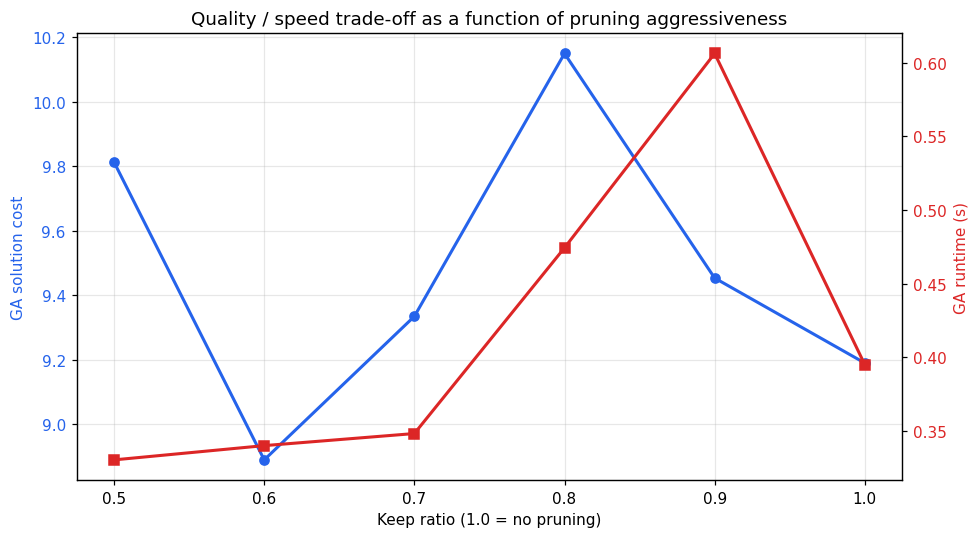

In [22]:
ratios = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]
ga_costs = []
ga_times = []
edge_counts = []

for kr in ratios:
    if kr == 1.0:
        Gt = G
    else:
        Gt = prune_graph(G, model, coords, keep_ratio=kr)
    dist_t = precompute_distances(Gt)
    edge_counts.append(Gt.number_of_edges())

    t0 = time.perf_counter()
    r, u, _, _ = genetic_algorithm(dist_t, problem, pop_size=50, n_gen=100, seed=1)
    rt = time.perf_counter() - t0
    cost = sum(evaluate_route(dist_t, rr, problem)[0] for rr in r)
    ga_costs.append(cost)
    ga_times.append(rt)
    print(f"keep_ratio={kr:.1f}  edges={Gt.number_of_edges():>3}  "
          f"GA cost={cost:.3f}  runtime={rt:.2f}s")

fig, ax1 = plt.subplots(figsize=(9, 5))
color1, color2 = "#2563eb", "#dc2626"
ax1.plot(ratios, ga_costs, "o-", color=color1, linewidth=2, label="GA cost")
ax1.set_xlabel("Keep ratio (1.0 = no pruning)")
ax1.set_ylabel("GA solution cost", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(ratios, ga_times, "s-", color=color2, linewidth=2, label="GA runtime")
ax2.set_ylabel("GA runtime (s)", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Quality / speed trade-off as a function of pruning aggressiveness")
fig.tight_layout()
plt.show()